# ML05: Ensembles - Voting, Bagging, Stacking and Boosting

Ensemble methods combine the predictions of several base estimators built with a given learning algorithm in order to improve generalizability or robustness over a single estimator.

## Voting

For classification tasks, the voting method aggregates the predictions of different models to make a final decision. For regression tasks, voting ensembles typically average the numerical predictions from multiple models to obtain a more stable estimate.

### Hard Voting

Each model in the ensemble makes a prediction, and the final classification is determined by the majority vote. The class that receives the most votes is chosen as the final prediction.

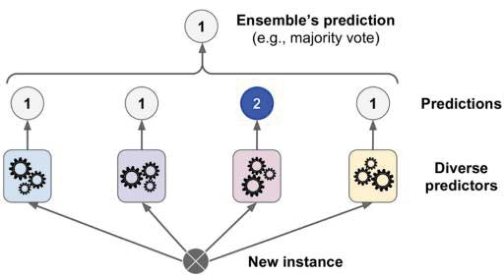 \
*(Image from the Internet)*

### Soft Voting

Instead of counting the number of votes, soft voting averages the predicted probabilities of each class across all models. The class with the highest average probability is selected. This approach is generally more effective if classifiers output meaningful probability estimates.

Example:

> Model 1 predicts A with $P(A) = 0.6$, $P(B) = 0.4$ \
> Model 2 predicts B with $P(A) = 0.1$, $P(B) = 0.9$ \
> Model 3 predicts A with $P(A) = 0.7$, $P(B) = 0.3$
>
> Final prediction using **hard voting** → Class A (majority wins)
> 
> Weighted probabilities → $P(A) = (0.6 + 0.1 + 0.7) / 3 = 0.47$, $P(B) = 0.53$ \
> Final prediction using **soft voting** → Class B (higher probability wins)

In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [2]:
X1, y1 = make_moons(500, random_state=42, noise=0.3)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, random_state=42)

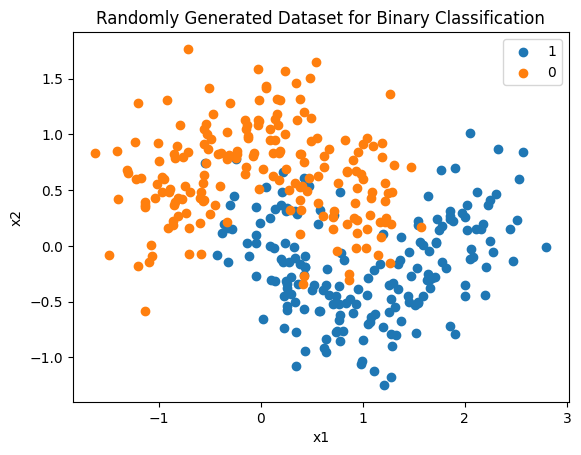

In [3]:
mask = y1_train == 1
plt.scatter(X1_train[:, 0][mask], X1_train[:, 1][mask], label="1")
plt.scatter(X1_train[:, 0][~mask], X1_train[:, 1][~mask], label="0")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Randomly Generated Dataset for Binary Classification")
plt.legend();

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

In [5]:
lg_clf = LogisticRegression()
kn_clf = KNeighborsClassifier()
dt_clf = DecisionTreeClassifier(random_state=42)

In [6]:
def evaluate_voting(clfs, **voting_kwargs):
    results = []
    voting_clf = VotingClassifier([(model.__class__.__name__, model) for model in clfs], **voting_kwargs)
    for model in clfs + [voting_clf]:
        model.fit(X1_train, y1_train)
        y1_pred = model.predict(X1_test)
        results.append((model.__class__.__name__, accuracy_score(y1_test, y1_pred)))
    return results

In [7]:
evaluate_voting([lg_clf, kn_clf, dt_clf])

[('LogisticRegression', 0.864),
 ('KNeighborsClassifier', 0.912),
 ('DecisionTreeClassifier', 0.856),
 ('VotingClassifier', 0.92)]

In [8]:
evaluate_voting([lg_clf, kn_clf, dt_clf], voting="soft")

[('LogisticRegression', 0.864),
 ('KNeighborsClassifier', 0.912),
 ('DecisionTreeClassifier', 0.856),
 ('VotingClassifier', 0.888)]

## Bagging and Random Forests

Bagging (bootstrap aggregating) is an ensemble method that builds multiple models from different bootstrapped samples of the training data and combines their outputs to improve predictive performance.

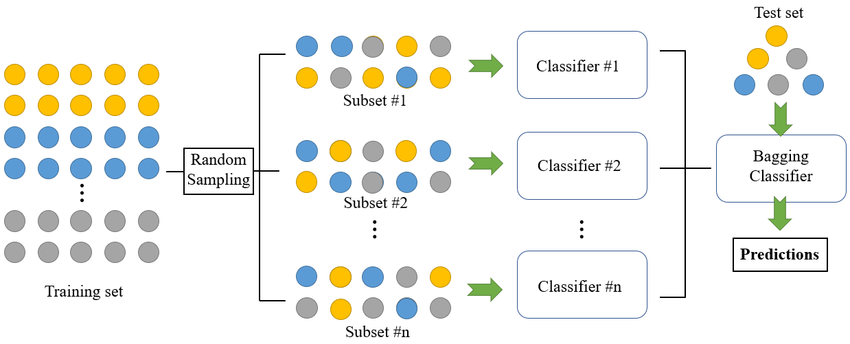 \
*(Image from the Internet)*

Random forest is a specialized form of bagging where the base estimators are decision trees.

In [9]:
import numpy as np
from sklearn.ensemble import BaggingClassifier

In [10]:
N_TREES = 10
bagging_clf = BaggingClassifier(n_estimators=N_TREES, n_jobs=-1, random_state=42)  # default estimator is DecisionTreeEstimator
bagging_clf.fit(X1_train, y1_train)

BaggingClassifier(n_jobs=-1, random_state=42)

In [11]:
accuracy_score(y1_test, bagging_clf.predict(X1_test))

0.872

Accuracy increases compared to a decision tree.

In [12]:
def draw_decision_boundary(clf, X, y, ax, title):
    xx1, xx2 = np.meshgrid(np.linspace(X[:, 0].min() - 0.1, X[:, 0].max() + 0.1, 100),
                         np.linspace(X[:, 1].min() - 0.1, X[:, 1].max() + 0.1, 100))

    X_mesh = np.c_[xx1.ravel(), xx2.ravel()]
    y_pred = clf.predict(X_mesh).reshape(xx1.shape)

    mask = y1_train == 1
    ax.scatter(X1_train[:, 0][mask], X1_train[:, 1][mask], label="1")
    ax.scatter(X1_train[:, 0][~mask], X1_train[:, 1][~mask], label="0")
    
    ax.contourf(xx1, xx2, y_pred, alpha=0.3, cmap="Set1")
    
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()
    ax.set_title(title)

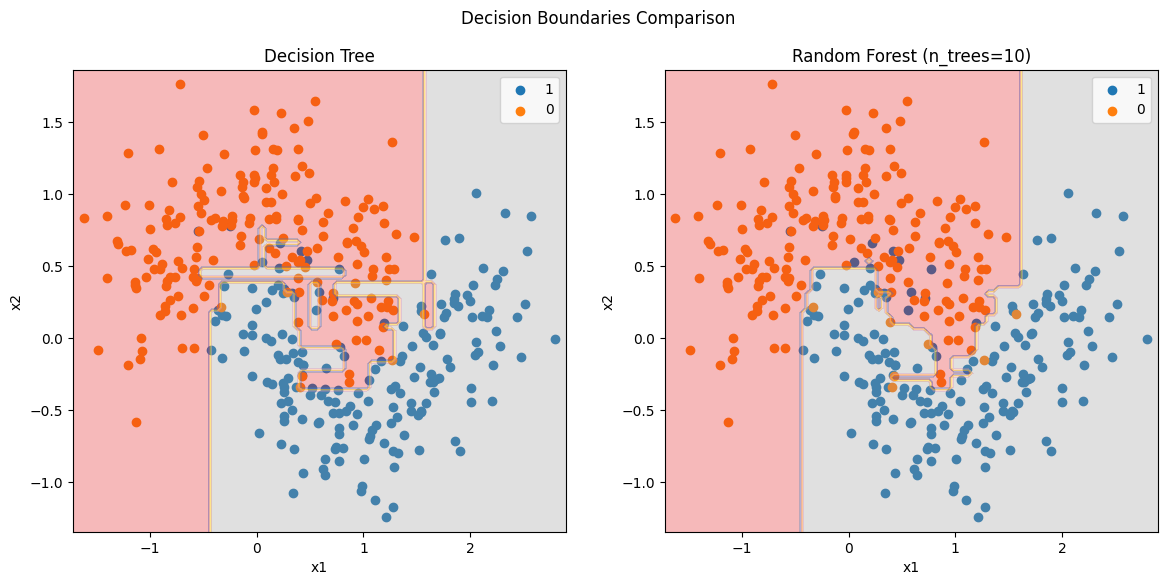

In [13]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(14, 6))
fig.suptitle("Decision Boundaries Comparison")
draw_decision_boundary(dt_clf, X1_train, y1_train, axes[0], "Decision Tree")
draw_decision_boundary(bagging_clf, X1_train, y1_train, axes[1], f"Random Forest (n_trees={N_TREES})")

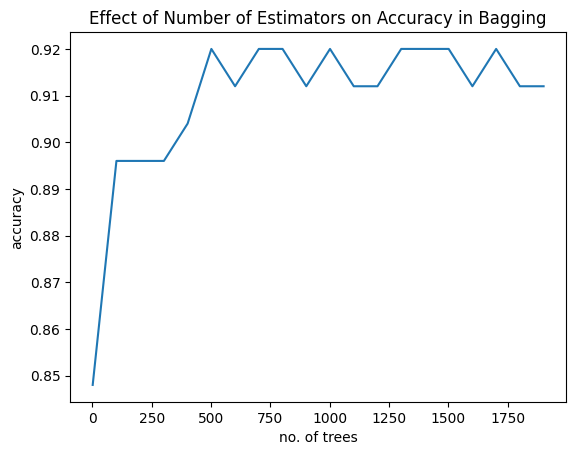

In [14]:
# CAUTION: This cell is computationally heavy!
def fit_rf(n):
    rf_clf = BaggingClassifier(n_estimators=n, n_jobs=-1, random_state=42)
    rf_clf.fit(X1_train, y1_train)
    return accuracy_score(y1_test, rf_clf.predict(X1_test))

n_trees = np.arange(1, 2000, 100)
n_oob = list(map(fit_rf, n_trees))
plt.plot(n_trees, n_oob)
plt.xlabel("no. of trees")
plt.ylabel("accuracy")
plt.title("Effect of Number of Estimators on Accuracy in Bagging");

### `BaggingClassifier` vs `RandomForestClassifier`

There is a similar model to `BaggingClassifier` with a default estimator, known as the `RandomForestClassifier`.

`RandomForestClassifier` adds randomness within each decision tree by selecting a random subset of features at each split (controlled by the `max_features` parameter). This extra step helps to decorrelate the trees and often improves performance, whereas `BaggingClassifier` does not incorporate this additional feature-level randomness.

## Stacking

Stacking is an ensemble learning technique that combines multiple base models (level-0 models) and uses a meta-model (level-1 model) to improve predictive performance. Instead of simply averaging predictions (like bagging), stacking learns how to best combine the outputs of multiple models.

<div>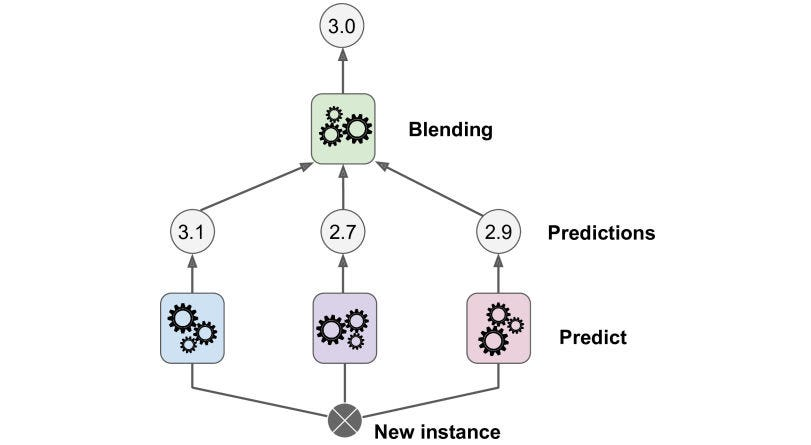</div>

In [15]:
from sklearn.ensemble import StackingClassifier

In [16]:
def evaluate_stacking(clfs, **stacking_kwargs):
    results = []
    stacking_clf = StackingClassifier([(model.__class__.__name__, model) for model in clfs], **stacking_kwargs)
    for model in clfs + [stacking_clf]:
        model.fit(X1_train, y1_train)
        y1_pred = model.predict(X1_test)
        results.append((model.__class__.__name__, accuracy_score(y1_test, y1_pred)))
    return results

In [17]:
evaluate_stacking([lg_clf, kn_clf, dt_clf])  # change meta-model using final_estimator hyperparameter, default to LogisticRegression

[('LogisticRegression', 0.864),
 ('KNeighborsClassifier', 0.912),
 ('DecisionTreeClassifier', 0.856),
 ('StackingClassifier', 0.92)]

In [18]:
evaluate_stacking([lg_clf, kn_clf, dt_clf], final_estimator=BaggingClassifier())

[('LogisticRegression', 0.864),
 ('KNeighborsClassifier', 0.912),
 ('DecisionTreeClassifier', 0.856),
 ('StackingClassifier', 0.864)]

## Boosting

Boosting is a technique that builds models sequentially, where each model attempts to correct the errors of its predecessors, thereby reducing bias and variance.

### AdaBoost (Adaptive Boosting)

AdaBoost sequentially trains weak learners to focus on mistakes from previous iterations. For classification, it increases the weights of misclassified samples, and the final prediction is the mean prediction of the weak classifiers in the ensemble. For regression, it similarly emphasizes samples with high errors, with the final prediction being the sum of the weak regressors' outputs.

Decision stumps (trees of depth 1) are often used as the weak learners.

<div>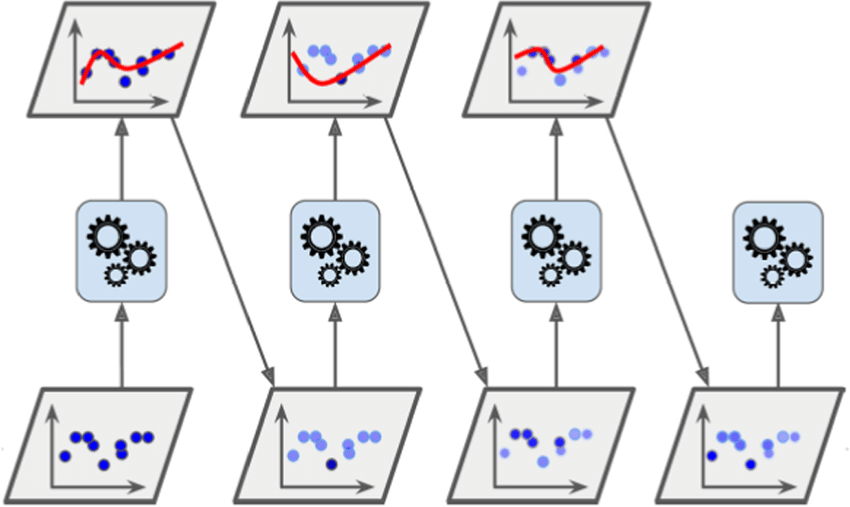</div>

*(Image from the Internet)*

One important hyperparameter is the learning rate, which is the weight applied to each classifier at each boosting iteration. There is a trade-off between the learning rate and the number of learners: a lower learning rate reduces each weak learner's contribution, so you need more estimators to achieve a similar overall effect, and vice versa.

In [19]:
from sklearn.ensemble import AdaBoostClassifier

In [20]:
ada_clf = AdaBoostClassifier(n_estimators=N_TREES, random_state=42)  # default estimator is DecisionTreeEstimator with max_depth=1
ada_clf.fit(X1_train, y1_train)

AdaBoostClassifier(n_estimators=10, random_state=42)

In [21]:
ada_clf.score(X1_test, y1_test)

0.888

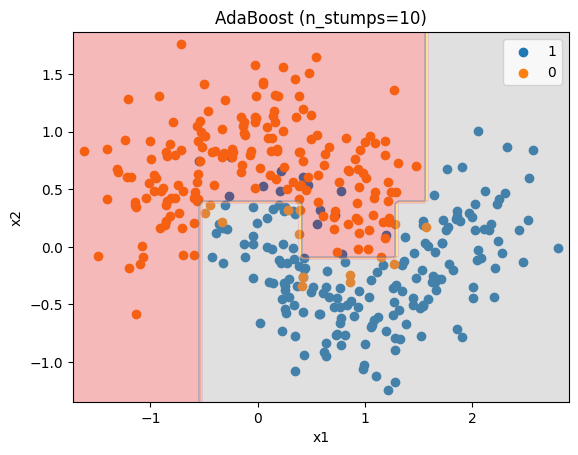

In [22]:
fig1, ax1 = plt.subplots()
draw_decision_boundary(ada_clf, X1_train, y1_train, ax1, f"AdaBoost (n_stumps={N_TREES})")

### Gradient Boosting

Gradient Boosting fits new models to the residual errors of prior models by optimizing a loss function, iteratively reducing errors through the additive correction of the ensemble.

<div>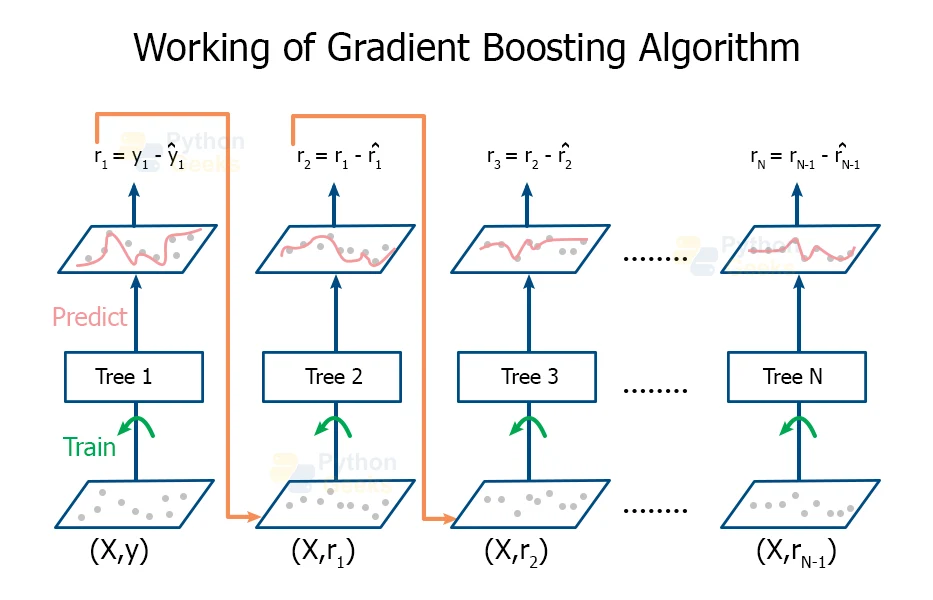</div>

*(Image from the Internet)*

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

In [24]:
# estimator is DecisionTreeEstimator with default max_depth=3
gb_clf = GradientBoostingClassifier(n_estimators=N_TREES, random_state=42)
gb_clf.fit(X1_train, y1_train)

GradientBoostingClassifier(n_estimators=10, random_state=42)

In [25]:
gb_clf.score(X1_test, y1_test)

0.896

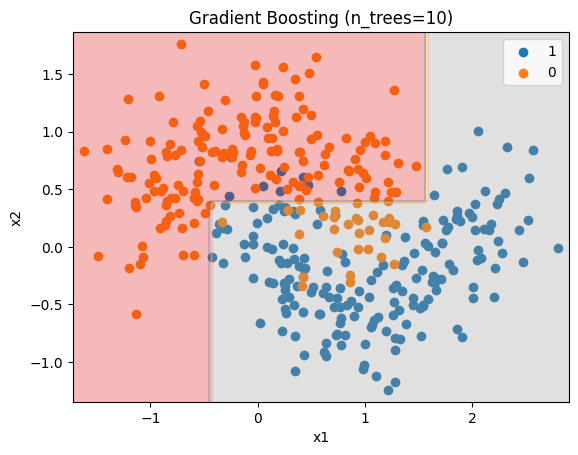

In [26]:
fig2, ax2 = plt.subplots()
draw_decision_boundary(gb_clf, X1_train, y1_train, ax2, f"Gradient Boosting (n_trees={N_TREES})")

### Early Stopping

In [27]:
big_gb_clf = GradientBoostingClassifier(n_estimators=1000, random_state=42)
big_gb_clf.fit(X1_train, y1_train)

GradientBoostingClassifier(n_estimators=1000, random_state=42)

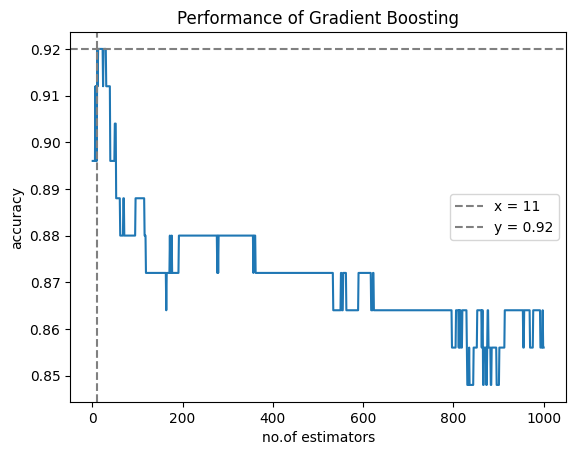

In [28]:
n_es = np.arange(1, 1001)
gb_accuracy_scores = []
for y1_pred in big_gb_clf.staged_predict(X1_test):
    gb_accuracy_scores.append(accuracy_score(y1_test, y1_pred))

plt.plot(n_es, gb_accuracy_scores)
plt.xlabel("no.of estimators")
plt.ylabel("accuracy")
plt.title("Performance of Gradient Boosting")

max_idx = np.argmax(gb_accuracy_scores)
max_x = n_es[max_idx]
max_y = gb_accuracy_scores[max_idx]
plt.axvline(max_x, color="gray", linestyle="dashed", label=f"x = {max_x}")
plt.axhline(max_y, color="gray", linestyle="dashed", label=f"y = {max_y:.2f}")
plt.legend()

In [29]:
best_gb_clf = GradientBoostingClassifier(n_estimators=max_x, random_state=42)
best_gb_clf.fit(X1_train, y1_train)
best_gb_clf.score(X1_test, y1_test)

0.92

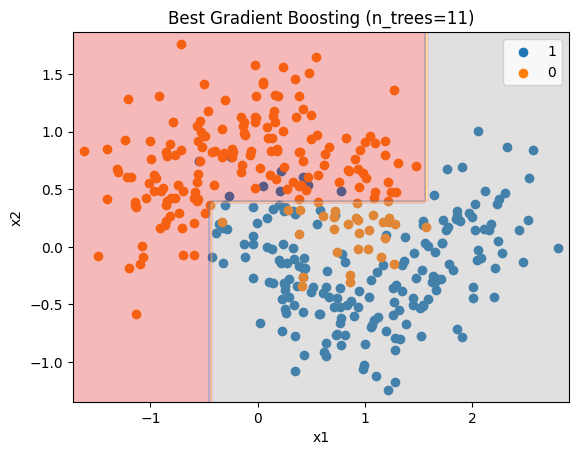

In [30]:
fig3, ax3 = plt.subplots()
draw_decision_boundary(gb_clf, X1_train, y1_train, ax3, f"Best Gradient Boosting (n_trees={max_x})")

## Key Takeaways

- Ensemble techniques harness the power of multiple learners to improve predictive accuracy and generalization compared to individual models.

- Voting combines predictions from multiple base models using majority vote (hard voting) or probability averaging (soft voting) to improve overall robustness. (`sklearn.ensemble.VotingClassifier/VotingRegressor`)

- Bagging reduces model variance by training multiple models on different bootstrapped subsets of the data and aggregating their predictions. (`sklearn.ensemble.BaggingClassifier/BaggingRegressor`)

- `RandomForestClassifier/RandomForestRegressor` is a specialized form of bagging that, in addition to bootstrapping, randomly selects a subset of features at each split (via the `max_feature`s parameter) to further decorrelate trees and enhance performance. (`sklearn.ensemble.RandomForestClassifier/RandomForestRegressor`)

- Stacking aggregates predictions from multiple diverse models (level-0) by training a meta-model (level-1) on their outputs to produce a final prediction that leverages the strengths of each individual model. (`sklearn.ensemble.StackingClassifier/StackingRegressor`)

- Boosting builds models sequentially, with each new model focusing on the errors of its predecessors, thereby reducing bias and variance through iterative improvement. (`sklearn.ensemble.AdaBoostClassifier/AdaBoostRegressor`, `sklearn.ensemble.GradientBoostingClassifier/GradientBoostingRegressor`)